# Flipkart Data Cleaning

In [30]:
import pandas as pd

In [31]:
# Importing the data into Notebook
data = pd.read_csv('flipkart_com-ecommerce_sample.csv')

In [32]:
data.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,c2d766ca982eca8304150849735ffef9,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2FF9KEDEFGF,999.0,379.0,"[""http://img5a.flixcart.com/image/short/u/4/a/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
1,7f7036a6d550aaa89d34c77bd39a5e48,2016-03-25 22:59:23 +0000,http://www.flipkart.com/fabhomedecor-fabric-do...,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",SBEEH3QGU7MFYJFY,32157.0,22646.0,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",False,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,No rating available,No rating available,FabHomeDecor,"{""product_specification""=>[{""key""=>""Installati..."
2,f449ec65dcbc041b6ae5e6a32717d01b,2016-03-25 22:59:23 +0000,http://www.flipkart.com/aw-bellies/p/itmeh4grg...,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",SHOEH4GRSUBJGZXE,999.0,499.0,"[""http://img5a.flixcart.com/image/shoe/7/z/z/r...",False,Key Features of AW Bellies Sandals Wedges Heel...,No rating available,No rating available,AW,"{""product_specification""=>[{""key""=>""Ideal For""..."
3,0973b37acd0c664e3de26e97e5571454,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2F6HUZMQ6SJ,699.0,267.0,"[""http://img5a.flixcart.com/image/short/6/2/h/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
4,bc940ea42ee6bef5ac7cea3fb5cfbee7,2016-03-25 22:59:23 +0000,http://www.flipkart.com/sicons-all-purpose-arn...,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",PSOEH3ZYDMSYARJ5,220.0,210.0,"[""http://img5a.flixcart.com/image/pet-shampoo/...",False,Specifications of Sicons All Purpose Arnica Do...,No rating available,No rating available,Sicons,"{""product_specification""=>[{""key""=>""Pet Type"",..."


## Data Cleaning

In [33]:
flipkart_data = data

In [34]:
flipkart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20002 entries, 0 to 20001
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   uniq_id                  20000 non-null  object 
 1   crawl_timestamp          20000 non-null  object 
 2   product_url              20000 non-null  object 
 3   product_name             20000 non-null  object 
 4   product_category_tree    20000 non-null  object 
 5   pid                      20000 non-null  object 
 6   retail_price             19922 non-null  float64
 7   discounted_price         19922 non-null  float64
 8   image                    19997 non-null  object 
 9   is_FK_Advantage_product  20000 non-null  object 
 10  description              19998 non-null  object 
 11  product_rating           20000 non-null  object 
 12  overall_rating           20000 non-null  object 
 13  brand                    14136 non-null  object 
 14  product_specifications

In [35]:
flipkart_data.isnull().sum()

uniq_id                       2
crawl_timestamp               2
product_url                   2
product_name                  2
product_category_tree         2
pid                           2
retail_price                 80
discounted_price             80
image                         5
is_FK_Advantage_product       2
description                   4
product_rating                2
overall_rating                2
brand                      5866
product_specifications       16
dtype: int64

In [36]:
flipkart_data.columns

Index(['uniq_id', 'crawl_timestamp', 'product_url', 'product_name',
       'product_category_tree', 'pid', 'retail_price', 'discounted_price',
       'image', 'is_FK_Advantage_product', 'description', 'product_rating',
       'overall_rating', 'brand', 'product_specifications'],
      dtype='object')

In [37]:
flipkart_data.drop(flipkart_data.columns[[0,1,2,5,8,9,11,12]], axis=1, inplace=True)


In [27]:
#Lets View the data Now
flipkart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20002 entries, 0 to 20001
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   product_name            20000 non-null  object 
 1   product_category_tree   20000 non-null  object 
 2   retail_price            19922 non-null  float64
 3   discounted_price        19922 non-null  float64
 4   description             19998 non-null  object 
 5   brand                   14136 non-null  object 
 6   product_specifications  19986 non-null  object 
dtypes: float64(2), object(5)
memory usage: 1.1+ MB


In [40]:
# A function to Clean the product_category_tree and return Primary_Category
def clean_prod_category():
    primary_category = []

    for ele in flipkart_data['product_category_tree'].astype(str):
        ele = ele.replace('"]', "")
        category = ele[2:].split(" >>")
        primary_category.append(category[0])

    return primary_category

In [41]:
#Calling the function
primary_category=clean_prod_category()

#Verfying the output
primary_category

['Clothing',
 'Furniture',
 'Footwear',
 'Clothing',
 'Pet Supplies',
 'Eternal Gandhi Super Series Crystal Paper Weight...',
 'Clothing',
 'Furniture',
 'Footwear',
 'Clothing',
 'Footwear',
 'Clothing',
 'Pet Supplies',
 'Clothing',
 'Pens & Stationery',
 'Clothing',
 'Furniture',
 'Footwear',
 'Clothing',
 'Furniture',
 'Pet Supplies',
 'Clothing',
 'Clothing',
 'Footwear',
 'Pet Supplies',
 'Clothing',
 'Sports & Fitness',
 'Beauty and Personal Care',
 'Clothing',
 'Clothing',
 'Bengal Blooms Rose Artificial Plant  with Pot (3...',
 'Clothing',
 'Pens & Stationery',
 'Pens & Stationery',
 'Pens & Stationery',
 'Clothing',
 'Pens & Stationery',
 'Clothing',
 'Bags, Wallets & Belts',
 'Clothing',
 'Footwear',
 'Home Decor & Festive Needs',
 'Automotive',
 'Tools & Hardware',
 "Vishudh Printed Women's Straight Kurta",
 "Vishudh Printed Women's Straight Kurta",
 "Vishudh Printed Women's Anarkali Kurta",
 'BuildTrack PIR Wireless Motion Sensor - One Swit...',
 'Skayvon SUMMERSIBLE SINGL

In [42]:
primary_category=pd.DataFrame(primary_category,columns=["Category"])
print("Number of Unique Categories",len(primary_category["Category"].value_counts()))

Number of Unique Categories 266


In [44]:
from collections import Counter
primary_category_top=Counter(primary_category["Category"]).most_common(266)
primary_category_top

[('Clothing', 6198),
 ('Jewellery', 3531),
 ('Footwear', 1227),
 ('Mobiles & Accessories', 1099),
 ('Automotive', 1012),
 ('Home Decor & Festive Needs', 929),
 ('Beauty and Personal Care', 710),
 ('Home Furnishing', 700),
 ('Kitchen & Dining', 647),
 ('Computers', 578),
 ('Watches', 530),
 ('Baby Care', 483),
 ('Tools & Hardware', 391),
 ('Toys & School Supplies', 330),
 ('Pens & Stationery', 313),
 ('Bags, Wallets & Belts', 265),
 ('Furniture', 180),
 ('Sports & Fitness', 166),
 ('Cameras & Accessories', 82),
 ('Home Improvement', 81),
 ('Health & Personal Care Appliances', 43),
 ('Sunglasses', 40),
 ('Gaming', 35),
 ('Pet Supplies', 30),
 ('Home & Kitchen', 24),
 ('Home Entertainment', 19),
 ('eBooks', 15),
 ('Eyewear', 10),
 ("Clovia Women's Full Coverage Bra", 9),
 ("Vishudh Printed Women's Straight Kurta", 8),
 ("Lilliput Top Baby Girl's  Combo", 8),
 ('Olvin Aviator Sunglasses', 7),
 ("Clovia Women's T-Shirt Bra", 6),
 ("MASARA Solid Women's Straight Kurta", 5),
 ('Dressberry Gol

In [45]:
#making a new column "primary_category"  
flipkart_data["primary_category"]=primary_category
flipkart_data.head()

,product_name,product_category_tree,retail_price,discounted_price,description,brand,product_specifications,primary_category
0,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",999.0,379.0,Key Features of Alisha Solid Women's Cycling S...,Alisha,"{""product_specification""=>[{""key""=>""Number of ...",Clothing
1,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",32157.0,22646.0,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,FabHomeDecor,"{""product_specification""=>[{""key""=>""Installati...",Furniture
2,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",999.0,499.0,Key Features of AW Bellies Sandals Wedges Heel...,AW,"{""product_specification""=>[{""key""=>""Ideal For""...",Footwear
3,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",699.0,267.0,Key Features of Alisha Solid Women's Cycling S...,Alisha,"{""product_specification""=>[{""key""=>""Number of ...",Clothing
4,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",220.0,210.0,Specifications of Sicons All Purpose Arnica Do...,Sicons,"{""product_specification""=>[{""key""=>""Pet Type"",...",Pet Supplies


In [47]:
# Function to return top categories with n count 

def count_of_category(n,bottom=False,List=False):
    output=[]
    primary_category_top=Counter(primary_category["Category"]).most_common(266)
    if bottom:
      for i in primary_category_top:
        if i[1]<=n:
            output.append(i)
    else:
      for i in primary_category_top:
        if i[1]>=n:
          output.append(i)
    if not List:
      output=pd.DataFrame(output,columns=["Category","Count"])
    return output

In [49]:
top_500_category = count_of_category(500) 
top_500_category

,Category,Count
0,Clothing,6198
1,Jewellery,3531
2,Footwear,1227
3,Mobiles & Accessories,1099
4,Automotive,1012
5,Home Decor & Festive Needs,929
6,Beauty and Personal Care,710
7,Home Furnishing,700
8,Kitchen & Dining,647
9,Computers,578


In [51]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.1 MB 9.4 MB/s eta 0:00:01
   -------------- ------------------------- 2.9/8.1 MB 12.9 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.1 MB 10.6 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.1 MB 8.2 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.1 MB 7.8 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 6.7 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------------------------- ---- 2.1/2.3 MB 9.8 MB/s eta 0:00:01
   -----------


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\likha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


C:\Users\likha\AppData\Local\Temp\ipykernel_13360\3912987797.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x="Category", y="Count", data=top_500_category, kind='bar', aspect=2, palette='rainbow')


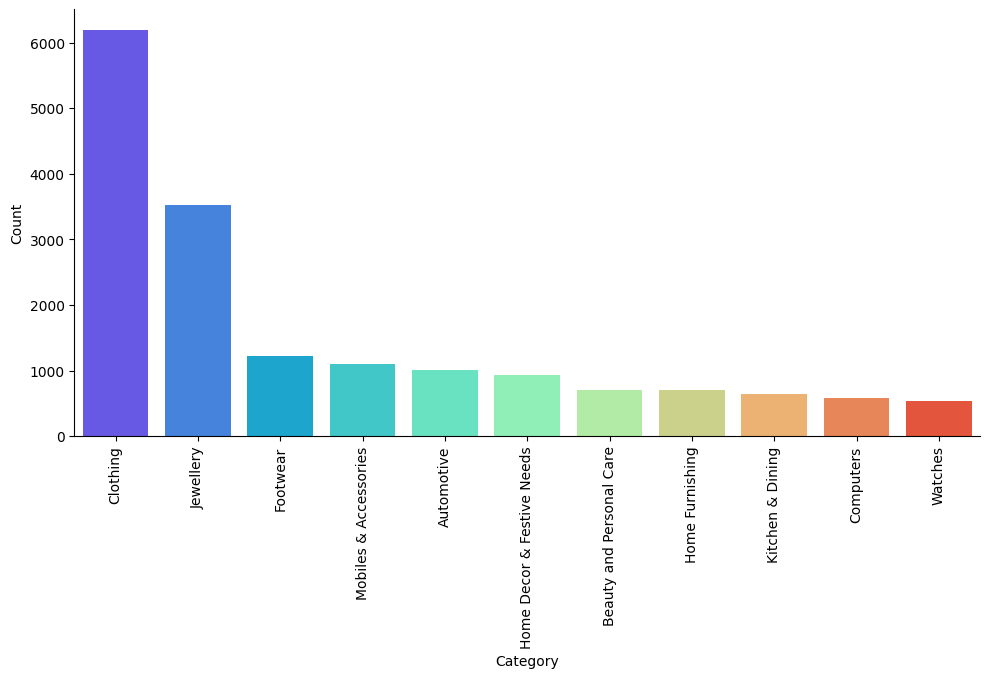

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.catplot(x="Category", y="Count", data=top_500_category, kind='bar', aspect=2, palette='rainbow')
plt.xticks(rotation=90)
plt.show()

In [57]:
#Let's see if its even feasible to visualize the categories with least counts
bottom_categories=count_of_category(500,bottom=True,List=True)
print("The number of categories with count less then 500 :",len(bottom_categories))

The number of categories with count less then 500 : 255
